# TUESDAY 20TH JAN, 2026
# UNSUPERVISED LEARNING

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

### Step 1: Load the data


In [2]:
df=pd.read_csv(r'income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       22 non-null     object
 1   Age        22 non-null     int64 
 2   Income($)  22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


### Step 2: visualize the raw data using scatter plot


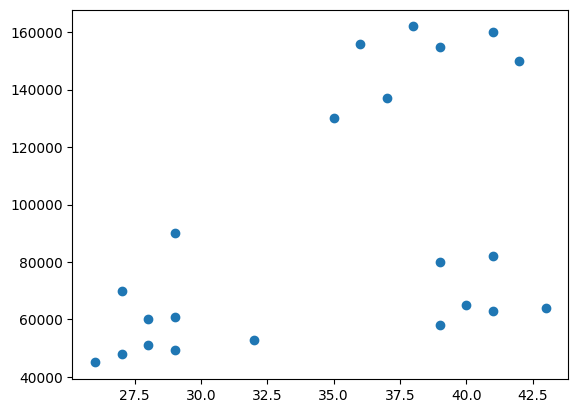

In [4]:
plt.scatter(df['Age'], df['Income($)'])  

### Step 3: Create Kmeans model

In [5]:
km = KMeans(n_clusters=3)
km

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


### Step 4: Fit the model and get cluster levels

In [6]:
y_predicted = km.fit_predict(df[['Age', 'Income($)']])
y_predicted


array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

### Step 5: Attach cluster labels to the dataframe

In [7]:
df ['Cluster'] = y_predicted
df.head()

,Name,Age,Income($),Cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


### Step 6: Plot clusters(Unscaled)

In [8]:
df1 = df[df.Cluster == 0]
df2 = df[df.Cluster == 1]
df3 = df[df.Cluster == 2]


C:\Users\Sally\AppData\Local\Temp\ipykernel_10364\225481889.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'Age')

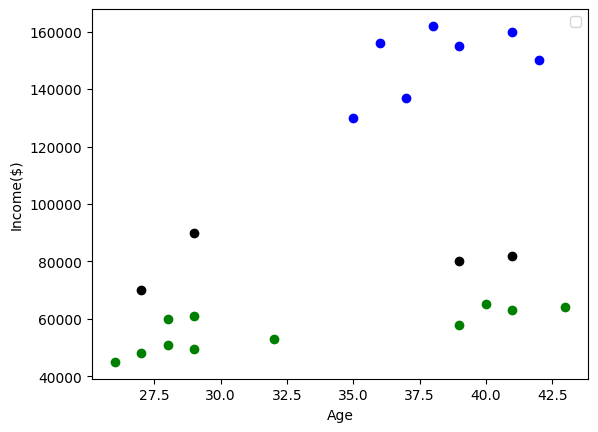

In [9]:
plt.scatter(df1['Age'], df1['Income($)'], color='green')
plt.scatter(df2['Age'], df2['Income($)'], color='blue')
plt.scatter(df3['Age'], df3['Income($)'], color='black')

plt.legend()
plt.ylabel('Income($)')
plt.xlabel('Age')

C:\Users\Sally\AppData\Local\Temp\ipykernel_10364\2132467719.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'Age')

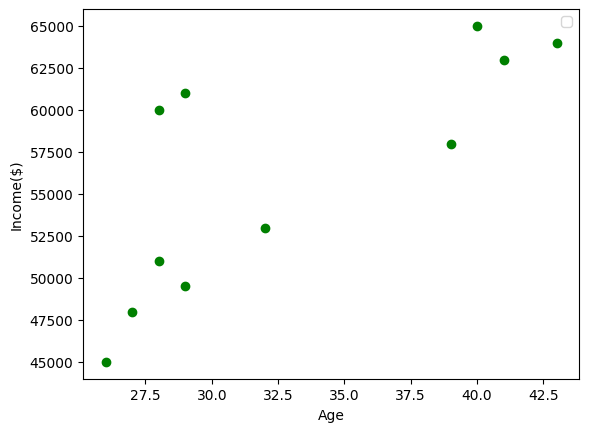

In [10]:
plt.scatter(df1['Age'], df1['Income($)'], color='green')
plt.legend()
plt.ylabel('Income($)')
plt.xlabel('Age')

C:\Users\Sally\AppData\Local\Temp\ipykernel_10364\2481891648.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'Age')

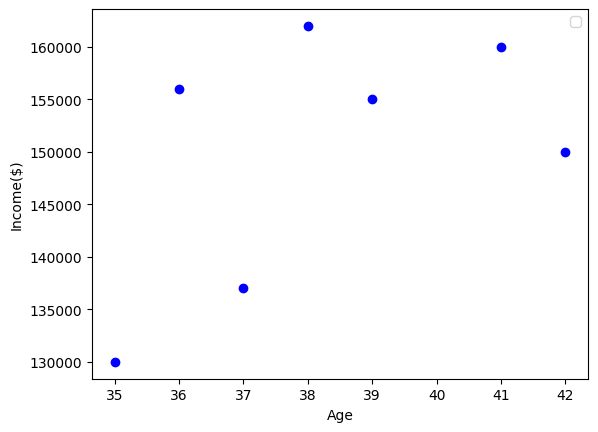

In [11]:
plt.scatter(df2['Age'], df2['Income($)'], color='blue')
plt.legend()
plt.ylabel('Income($)')
plt.xlabel('Age')


C:\Users\Sally\AppData\Local\Temp\ipykernel_10364\3054427313.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0.5, 0, 'Age')

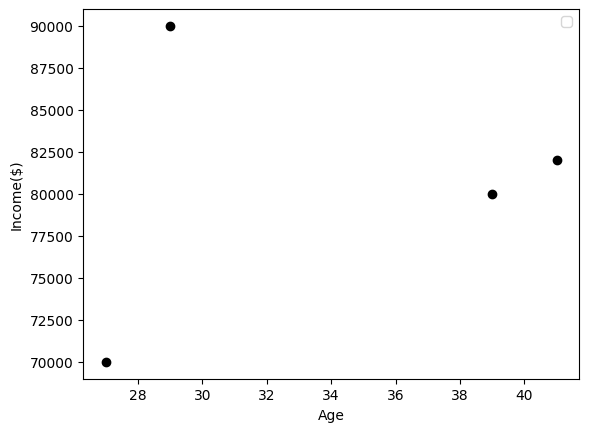

In [12]:
plt.scatter(df3['Age'], df3['Income($)'], color='black')
plt.legend()
plt.ylabel('Income($)')
plt.xlabel('Age')

In [13]:
scaler = MinMaxScaler()
scaler.fit(df[['Income($)']])
df['Income($)'] = scaler.transform(df[['Income($)']])

In [14]:
scaler = MinMaxScaler()
scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])

In [15]:
df.head()

,Name,Age,Income($),Cluster
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


In [16]:
km = KMeans(n_clusters=3)
km

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [17]:
y_predicted = km.fit_predict(df[['Age', 'Income($)']])
y_predicted


array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [18]:
df ['Cluster'] = y_predicted
df.head()

,Name,Age,Income($),Cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


In [19]:
df1 = df[df.Cluster == 0]
df2 = df[df.Cluster == 1]
df3 = df[df.Cluster == 2]


In [ ]:
km.cluster_centers_

Text(0.5, 0, 'Age')

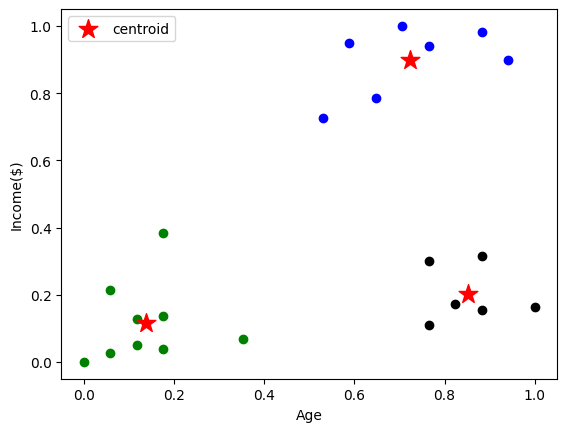

In [28]:
plt.scatter(df1['Age'], df1['Income($)'], color='green')
plt.scatter(df2['Age'], df2['Income($)'], color='blue')
plt.scatter(df3['Age'], df3['Income($)'], color='black')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1], color='red', marker='*', label='centroid', s= 200)

plt.legend()
plt.ylabel('Income($)')
plt.xlabel('Age')

In [30]:
k_range = range(1, 10)
sse = []
for k in k_range:
    km = KMeans(n_clusters=k)
    km.fit(df[['Age','Income($)']])
    sse.append(km.inertia_)


In [31]:
sse

[5.434011511988178,
 2.091136388699078,
 0.4750783498553096,
 0.3491047094419566,
 0.3105597072895155,
 0.2671557284269111,
 0.18777447445785067,
 0.1456953330463519,
 0.12318585975167762]

C:\Users\Sally\AppData\Local\Temp\ipykernel_10364\3899525497.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


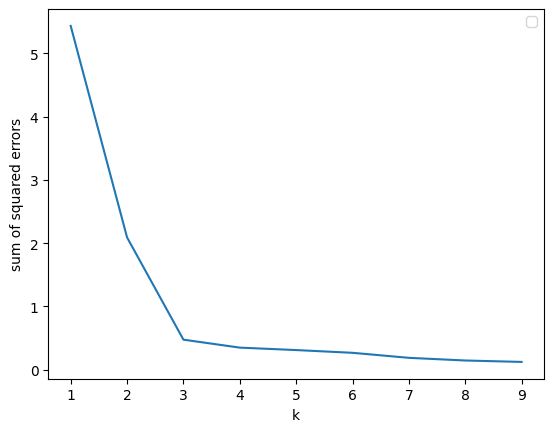

In [34]:
plt.plot(k_range, sse)
plt.ylabel('sum of squared errors')
plt.xlabel('k')
plt.legend()